# Project 1: Planet Earth's Global Temperature

In this project, we will download temperature data from NASA’s Goddard Institute for Space Studies (GISS) and analyze it using pandas (and possibly seaborn).

### Introduction

First, we must understand the data collection method. This method was original documented by Hansen and Lebedeff in [1987](https://pubs.giss.nasa.gov/docs/1987/1987_Hansen_ha00700d.pdf) and the study has been repeated many times, including in [2010](https://pubs.giss.nasa.gov/docs/2010/2010_Hansen_ha00510u.pdf). A summary of the data collection method is as follows.
1. Thousands of meteorological stations around the world (land and sea) measure the surface air temperature. All measurements discussed here will be in Celsius.
1. The world average temperature throughout each month for all stations is calculated. Systematic affects are corrected and uncertainty is estimated.
1. The "**reference monthly average temperature**" is calculated by averaging over all stations and measurements during each month of the three decade period 1951-1980.
1. The "**temperature anomaly**" is defined as the world monthly average temperature minus the reference monthly average temperature.

### Accessing temperature anomaly data

The GISS temperature anomaly data can be found here. https://data.giss.nasa.gov/gistemp/

From this link please find and download the CSV file
"Global-mean monthly, seasonal, and annual means, 1880-present, updated through most recent month". The file name should be `GLB.Ts+dSST.csv`.

### Data analysis

#### Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Read in the data

Use panda's `read_csv()` function with the argument `skiprows=1` to read in the data and setup a `DataFrame`.

In [3]:
df = pd.read_csv('GLB.Ts+dSST.csv', skiprows=1)

#### Inspect the data

Print the `DataFrame` you created.  You should see a "Year" column and a column for each month ("Jan", "Feb", etc.).  There are also columns for select averages.
* "J-D" = 1 year average temperature (January -> December)
* "D-N" = 1 year average temperature (December -> November)
* "DJF" = 3 month average temperature (Dec, Jan, Feb)
* "MAM" = 3 month average temperature (Mar, Apr, May)
* "JJA" = 3 month average temperature (Jun, Jul, Aug)
* "SON" = 3 month average temperature (Sep, Oct, Nov)       

In [4]:
print(df.head())

   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.24 -0.09 -0.16 -0.10 -0.21 -0.17 -0.10 -0.14 -0.23 -0.21   
1  1881 -0.19 -0.14  0.03  0.05  0.07 -0.19  0.00 -0.04 -0.15 -0.22 -0.19   
2  1882  0.16  0.14  0.05 -0.17 -0.14 -0.23 -0.16 -0.07 -0.14 -0.23 -0.16   
3  1883 -0.29 -0.37 -0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.11 -0.24   
4  1884 -0.13 -0.08 -0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.33   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0  -.18  -.17   ***   *** -0.12 -0.16 -0.19  
1  -.07  -.09  -.09  -.17  0.05 -0.07 -0.19  
2  -.36  -.11  -.08   .08 -0.09 -0.15 -0.18  
3  -.11  -.18  -.20  -.34 -0.16 -0.09 -0.19  
4  -.31  -.28  -.27  -.11 -0.37 -0.31 -0.28  


#### Data preparation

Set the "Year" column as the `DataFrame` index.

In [8]:
df.set_index(df.columns[0], inplace=True)

print(df.head())

        Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec   J-D  \
Jan                                                                             
-0.19 -0.24 -0.09 -0.16 -0.10 -0.21 -0.17 -0.10 -0.14 -0.23 -0.21  -.18  -.17   
-0.19 -0.14  0.03  0.05  0.07 -0.19  0.00 -0.04 -0.15 -0.22 -0.19  -.07  -.09   
 0.16  0.14  0.05 -0.17 -0.14 -0.23 -0.16 -0.07 -0.14 -0.23 -0.16  -.36  -.11   
-0.29 -0.37 -0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.11 -0.24  -.11  -.18   
-0.13 -0.08 -0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.33  -.31  -.28   

        D-N   DJF   MAM   JJA   SON  
Jan                                  
-0.19   ***   *** -0.12 -0.16 -0.19  
-0.19  -.09  -.17  0.05 -0.07 -0.19  
 0.16  -.08   .08 -0.09 -0.15 -0.18  
-0.29  -.20  -.34 -0.16 -0.09 -0.19  
-0.13  -.27  -.11 -0.37 -0.31 -0.28  


Drop the last six columns ('J-D','D-N','DJF','MAM','JJA', and 'SON'), which we will not use.

In [14]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Now drop the columns using the stripped column names
df.drop(columns=['J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON'], inplace=True, errors='ignore')

print(df.head())

        Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Jan                                                                    
-0.19 -0.24 -0.09 -0.16 -0.10 -0.21 -0.17 -0.10 -0.14 -0.23 -0.21  -.18
-0.19 -0.14  0.03  0.05  0.07 -0.19  0.00 -0.04 -0.15 -0.22 -0.19  -.07
 0.16  0.14  0.05 -0.17 -0.14 -0.23 -0.16 -0.07 -0.14 -0.23 -0.16  -.36
-0.29 -0.37 -0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.11 -0.24  -.11
-0.13 -0.08 -0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.33  -.31


#### Data cleaning

The data is updated regularly, but some months may not be available yet.  In such cases, the missing data appears as three asterisks (`***`). Replace such entries with something that pandas understands, `NaN`.

In [39]:
df.replace('***', np.nan, inplace=True)

print(df.head())

        Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Mar                                                        
-0.09 -0.16 -0.10 -0.21 -0.17 -0.10 -0.14 -0.23 -0.21 -0.18
 0.03  0.05  0.07 -0.19  0.00 -0.04 -0.15 -0.22 -0.19 -0.07
 0.05 -0.17 -0.14 -0.23 -0.16 -0.07 -0.14 -0.23 -0.16 -0.36
-0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.11 -0.24 -0.11
-0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.33 -0.31


Call `info()` on your `DataFrame`.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, -0.09 to 1.2
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Apr     144 non-null    float64
 1   May     144 non-null    float64
 2   Jun     144 non-null    float64
 3   Jul     144 non-null    float64
 4   Aug     144 non-null    float64
 5   Sep     144 non-null    float64
 6   Oct     144 non-null    float64
 7   Nov     144 non-null    float64
 8   Dec     143 non-null    object 
dtypes: float64(8), object(1)
memory usage: 11.2+ KB


If the `Dtype` of each column isn't `float64`, convert the `DataFrame` using the `astype()` function.

In [21]:
df = df.astype('float64')

print(df.head())

        Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Mar                                                        
-0.09 -0.16 -0.10 -0.21 -0.17 -0.10 -0.14 -0.23 -0.21 -0.18
 0.03  0.05  0.07 -0.19  0.00 -0.04 -0.15 -0.22 -0.19 -0.07
 0.05 -0.17 -0.14 -0.23 -0.16 -0.07 -0.14 -0.23 -0.16 -0.36
-0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.11 -0.24 -0.11
-0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.33 -0.31


#### Data visualization

Make a plot of the January Temperature Anomaly (column "Jan") versus year. Basically you are plotting the data contained in one column of the `DataFrame` versus the index of the `DataFrame` (the year). Label your axes and include temperature units.

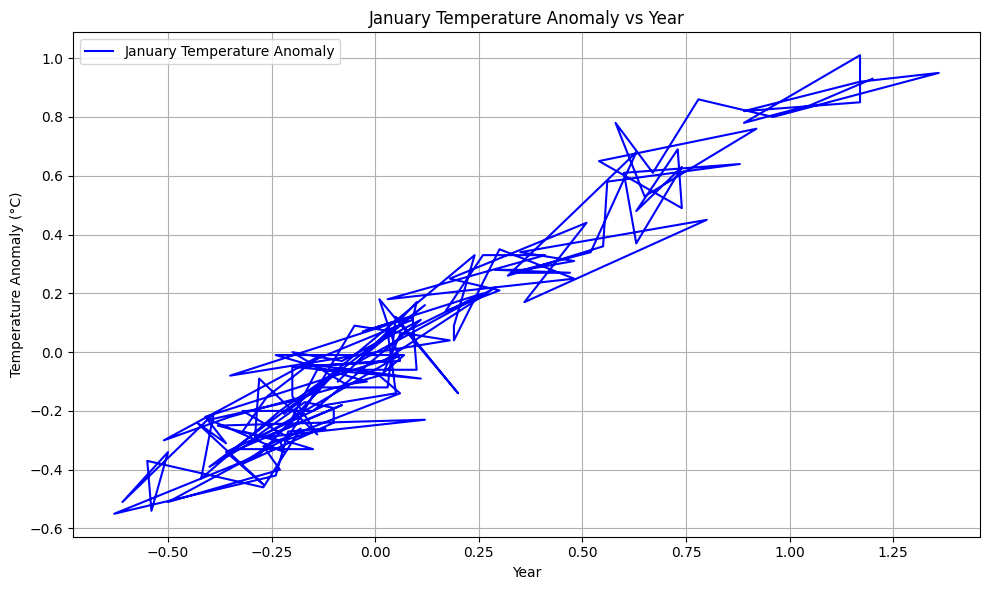

In [42]:
plt.figure(figsize=(10, 6))
# Use the DataFrame index (which is 'Year') for the x-axis, and 'Jan' as the y-axis
plt.plot(df.index, df.iloc[:, 1], label='January Temperature Anomaly', color='blue')
plt.title('January Temperature Anomaly vs Year')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Make the plot again, but with argument `kind='bar'`.

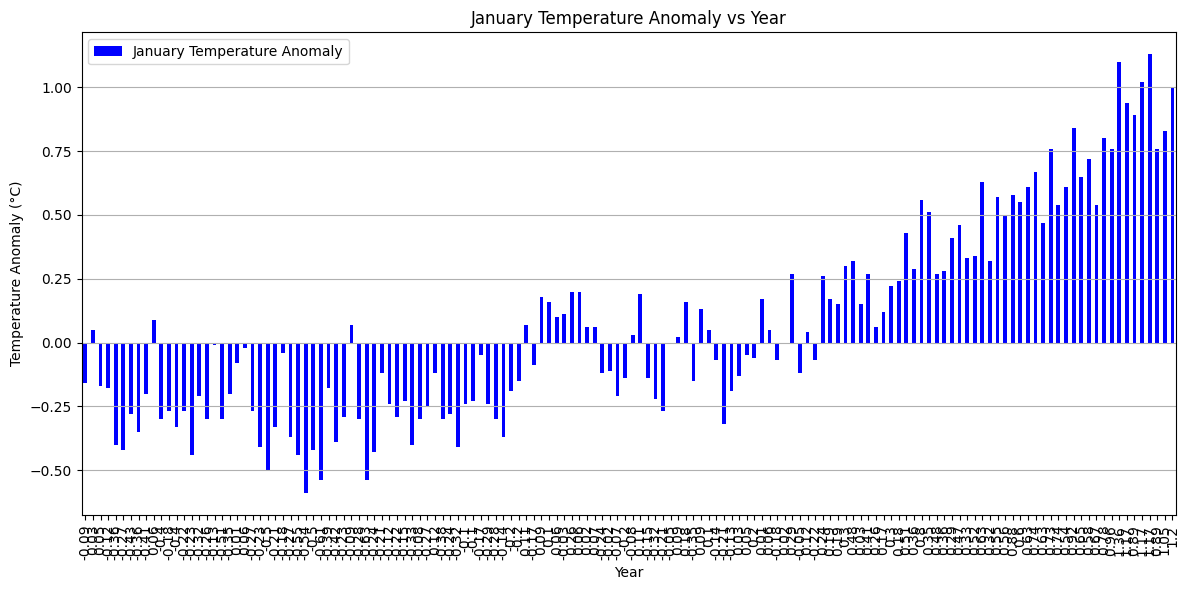

In [46]:
plt.figure(figsize=(12, 6))
df.iloc[:, 0].plot(kind='bar', color='blue', label='January Temperature Anomaly')
plt.title('January Temperature Anomaly vs Year')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

Make a new column in your new `DataFrame` containing the average temperature anomaly for the year (with column name "Yearly Avg"). Calculate this average on your own (instead of relying on the "J-D" column which we dropped above). This can be done with the pandas `mean()` function. Check the documentation for this function to ensure that you are calculating the average over a row, not a column.

In [48]:
df['Yearly Avg'] = df.mean(axis=1)

Make a plot of the yearly average temperature anomaly versus year (as a line graph again).

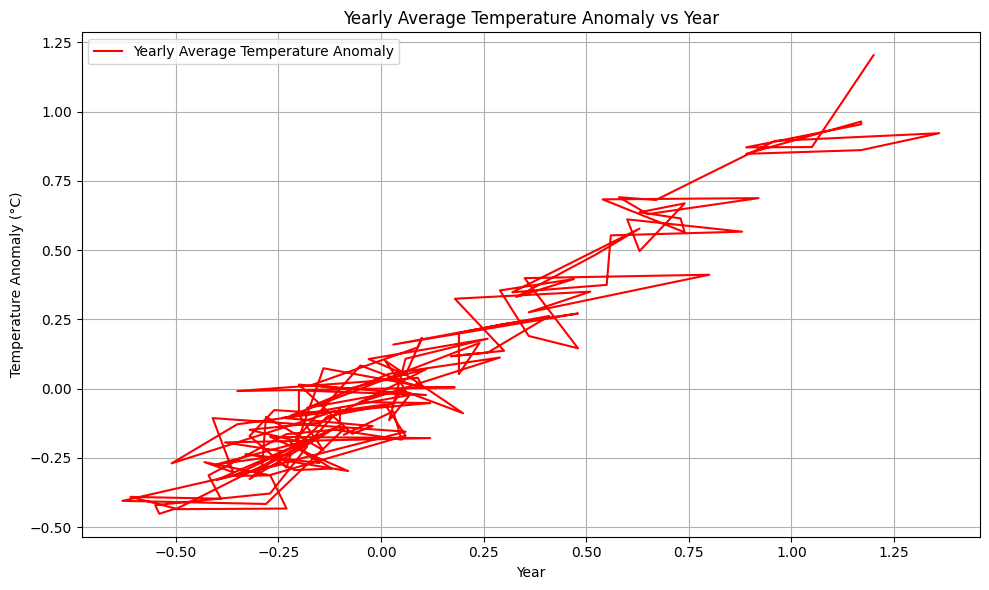

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Yearly Avg'], label='Yearly Average Temperature Anomaly', color='red')
plt.title('Yearly Average Temperature Anomaly vs Year')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

-----------------

Use a "Savitzky–Golay filter" to smooth the data.  The scipy package includes a [`savgol_filter` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html) which implements this filter.  Try different values of the `window_length` (odd values only) and `polyorder` arguments to find suitable values.  Overlay the raw (in black) and smoothed (in blue) yearly averages.  Include a legend.

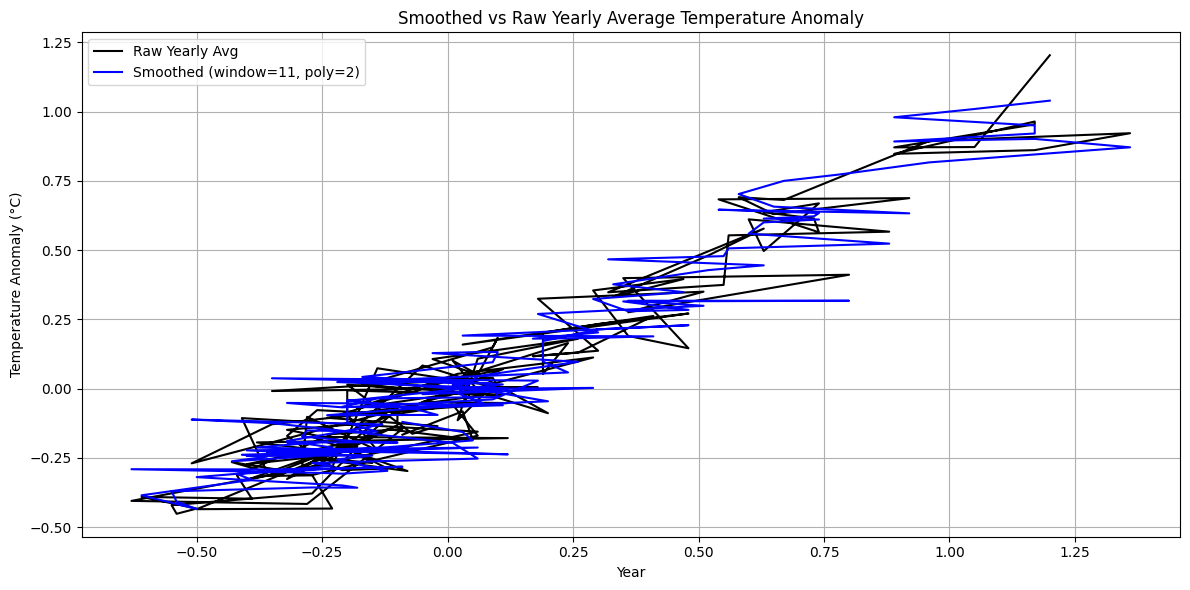

In [50]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Apply Savitzky–Golay filter to smooth the Yearly Avg data
# window_length must be odd and <= the number of data points
window_length = 11  # try 5, 9, 11, 15, etc.
polyorder = 2       # try 2 or 3

# Drop NaN values temporarily to apply smoothing
valid_data = df['Yearly Avg'].dropna()

# Apply filter only to valid data
smoothed = savgol_filter(valid_data, window_length=window_length, polyorder=polyorder)

# Plot raw and smoothed data
plt.figure(figsize=(12, 6))
plt.plot(valid_data.index, valid_data, color='black', label='Raw Yearly Avg')
plt.plot(valid_data.index, smoothed, color='blue', label=f'Smoothed (window={window_length}, poly={polyorder})')
plt.title('Smoothed vs Raw Yearly Average Temperature Anomaly')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Slice the `DataFrame` to obtain a new `DataFrame` with only the last 10 years worth of data.  Average over these years to find the temperature anomaly for each of the 12 months, and print the result.

In [51]:
last_10_years = df.tail(10)

monthly_avg_last_10_years = last_10_years.iloc[:, :12].mean()


print("Average Temperature Anomaly for Each Month (Last 10 Years):")
print(monthly_avg_last_10_years)


Average Temperature Anomaly for Each Month (Last 10 Years):
Apr           0.923000
May           0.876000
Jun           0.842000
Jul           0.870000
Aug           0.906000
Sep           0.938000
Oct           0.988000
Nov           0.954000
Dec           0.912222
Yearly Avg    0.915375
dtype: float64


------------

On a single set of axes, overlay the raw distribution (in black) with each of the 12 monthly average temperature anomalies (in various colors). Draw the yearly average with a thicker line width to make it stand out. Label your axes and draw a legend.

It may help to draw the legend outside the axes using the following syntax:
```python
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., prop={'size'. 11})
```

You can use matplotlib [`Colormaps`](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.colormaps) to easily vary the color of each of the 12 monthly distributions.

<ipython-input-53-37ff431bcc40>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', 12)


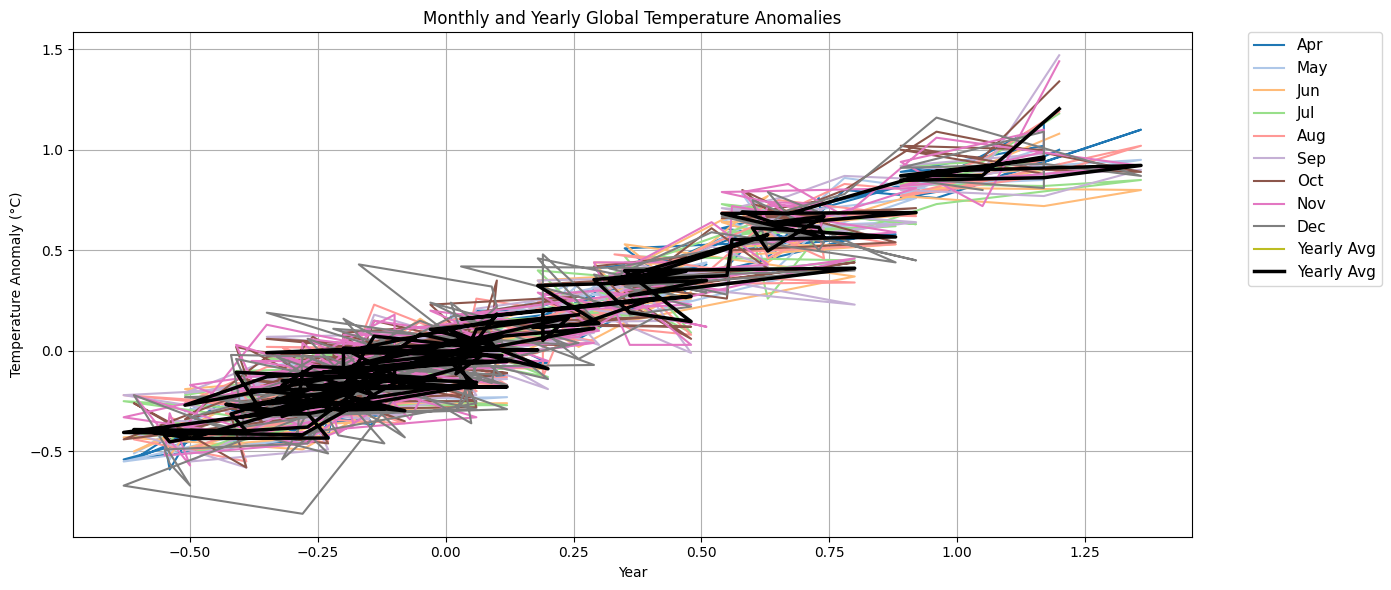

In [53]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


plt.figure(figsize=(14, 6))

colors = cm.get_cmap('tab20', 12)

for i, month in enumerate(df.columns[:12]):  # First 12 columns are Jan-Dec
    plt.plot(df.index, df[month], label=month, color=colors(i))

# Overlay the Yearly Avg with a thicker black line
plt.plot(df.index, df['Yearly Avg'], color='black', linewidth=2.5, label='Yearly Avg')

# Plot formatting
plt.title('Monthly and Yearly Global Temperature Anomalies')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)

# Draw the legend outside the axes
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., prop={'size': 11})

plt.tight_layout()
plt.show()


Plot the temperature anomaly versus month. This time, do this for every every year (so there will be hundreds of lines drawn).

Begin by using the `transpose()` function to convert the `DataFrame` indices to columns and vice versa.

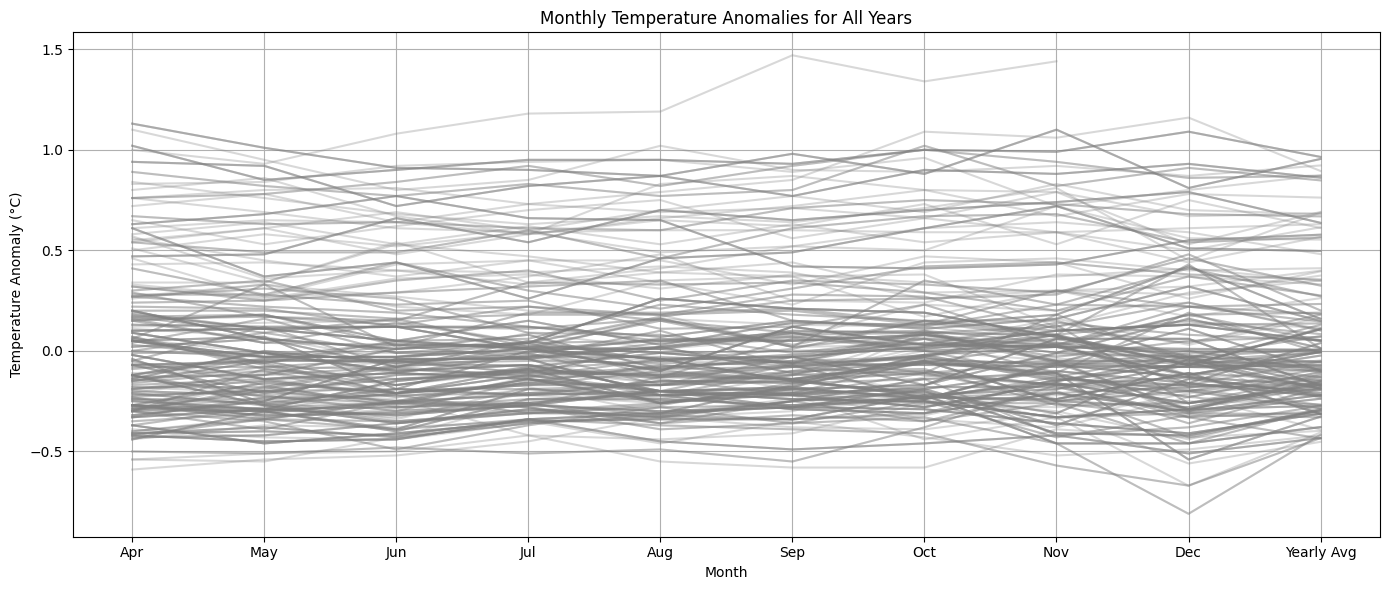

In [54]:
import matplotlib.pyplot as plt

monthly_df = df.iloc[:, :12]

monthly_transposed = monthly_df.transpose()

plt.figure(figsize=(14, 6))

for year in monthly_transposed.columns:
    plt.plot(monthly_transposed.index, monthly_transposed[year], color='gray', alpha=0.3)

plt.title('Monthly Temperature Anomalies for All Years')
plt.xlabel('Month')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()


Drop the "Yearly Average" row so that we only have monthly data in our plot.

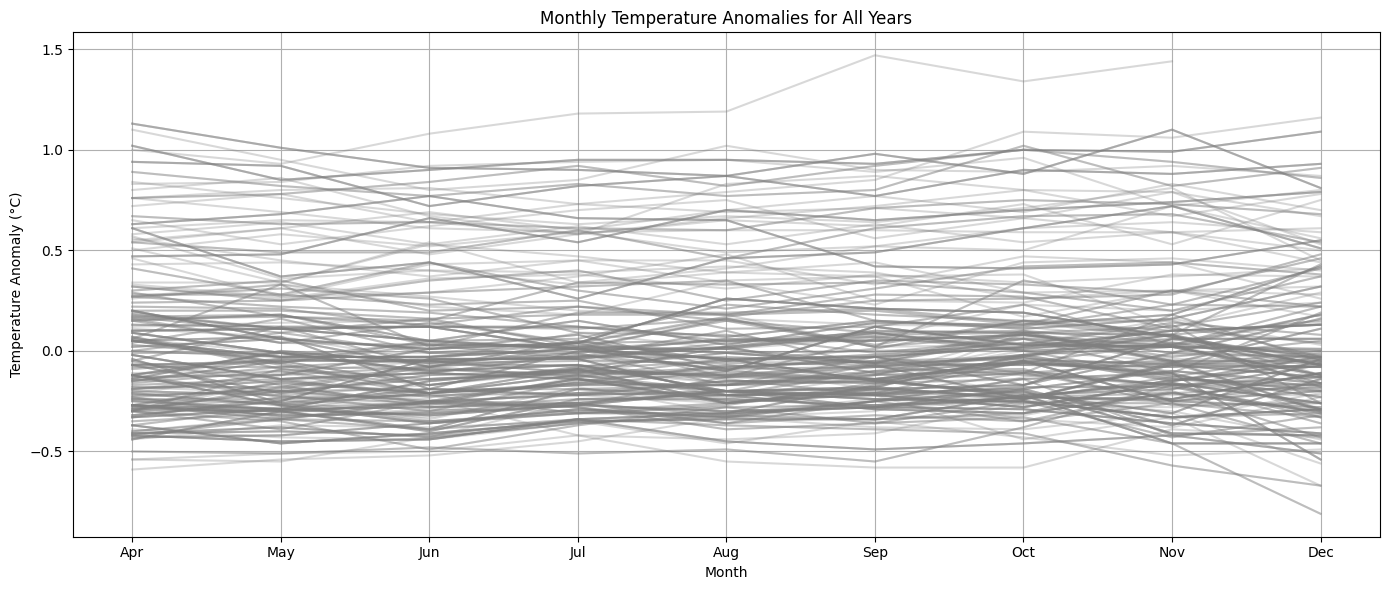

In [55]:
monthly_df = df.iloc[:, :12]

monthly_transposed = monthly_df.transpose()

monthly_transposed = monthly_transposed.drop(index='Yearly Avg', errors='ignore')

plt.figure(figsize=(14, 6))

for year in monthly_transposed.columns:
    plt.plot(monthly_transposed.index, monthly_transposed[year], color='gray', alpha=0.3)

plt.title('Monthly Temperature Anomalies for All Years')
plt.xlabel('Month')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()


Finally, plot all the distributions on a single set of axes.  Use magenta for the most recent year, and use the "brg" `Colormap` for all others (by passing the argument `cmap="brg"` to the `plot()` function). This will ensure that one can tell the old years from the more recent years.

<ipython-input-56-4593660f7ecb>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('brg', num_years - 1)


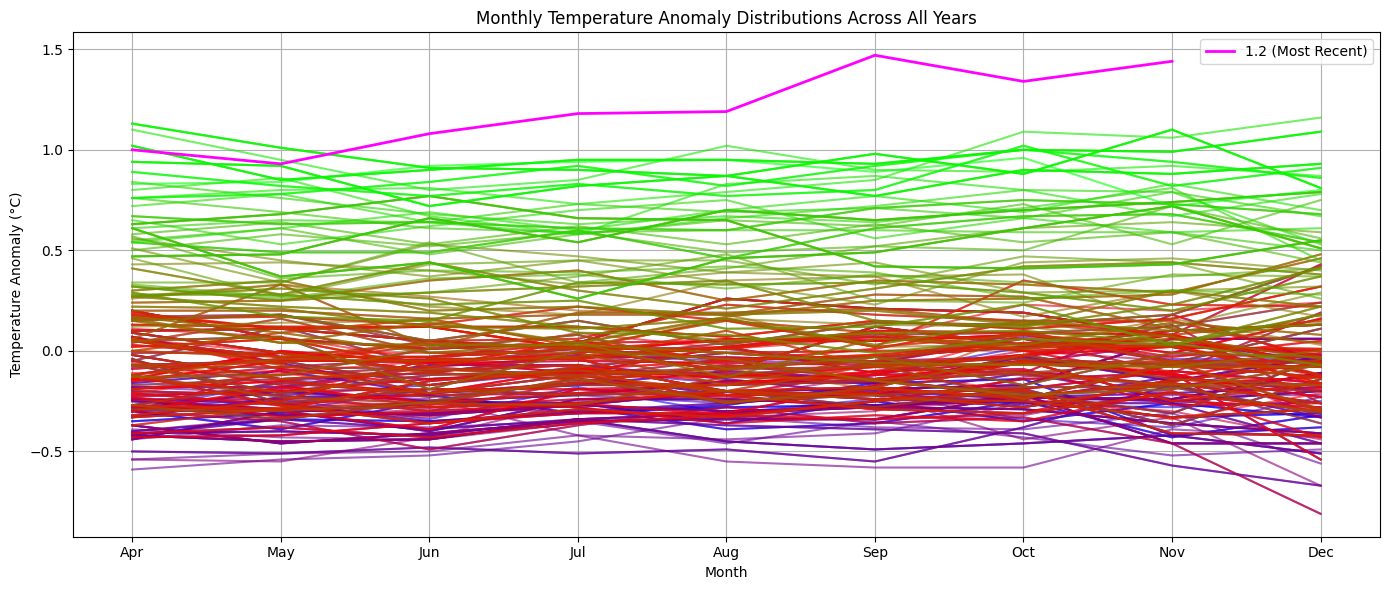

In [56]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

monthly_df = df.iloc[:, :12]
monthly_transposed = monthly_df.transpose()

monthly_transposed = monthly_transposed.drop(index='Yearly Avg', errors='ignore')

years = monthly_transposed.columns
num_years = len(years)

colormap = cm.get_cmap('brg', num_years - 1)

plt.figure(figsize=(14, 6))
for i, year in enumerate(years[:-1]):
    plt.plot(monthly_transposed.index, monthly_transposed[year], color=colormap(i), alpha=0.6)

most_recent_year = years[-1]
plt.plot(monthly_transposed.index, monthly_transposed[most_recent_year],
         color='magenta', linewidth=2, label=f'{most_recent_year} (Most Recent)')

plt.title('Monthly Temperature Anomaly Distributions Across All Years')
plt.xlabel('Month')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


It can be difficult to interpret such a busy plot.  You should make a simpler plot which can be more easily interpretted.

First, create a new `DataFrame` with columns for each decade and rows for each month, which holds the average temperature anomaly.

In [57]:
monthly_data = df.iloc[:, :12].copy()

monthly_data['Decade'] = (monthly_data.index // 10) * 10

decade_monthly_avg = monthly_data.groupby('Decade').mean()

decade_monthly_avg = decade_monthly_avg.transpose()

print("Monthly average temperature anomalies by decade:")
print(decade_monthly_avg.head())


Monthly average temperature anomalies by decade:
Decade     -10.0      0.0 
Apr    -0.247571  0.358784
May    -0.234429  0.325811
Jun    -0.236000  0.302838
Jul    -0.191143  0.307838
Aug    -0.197571  0.308919


On a single set of axes, plot the temperature anomaly versus month for each decade.

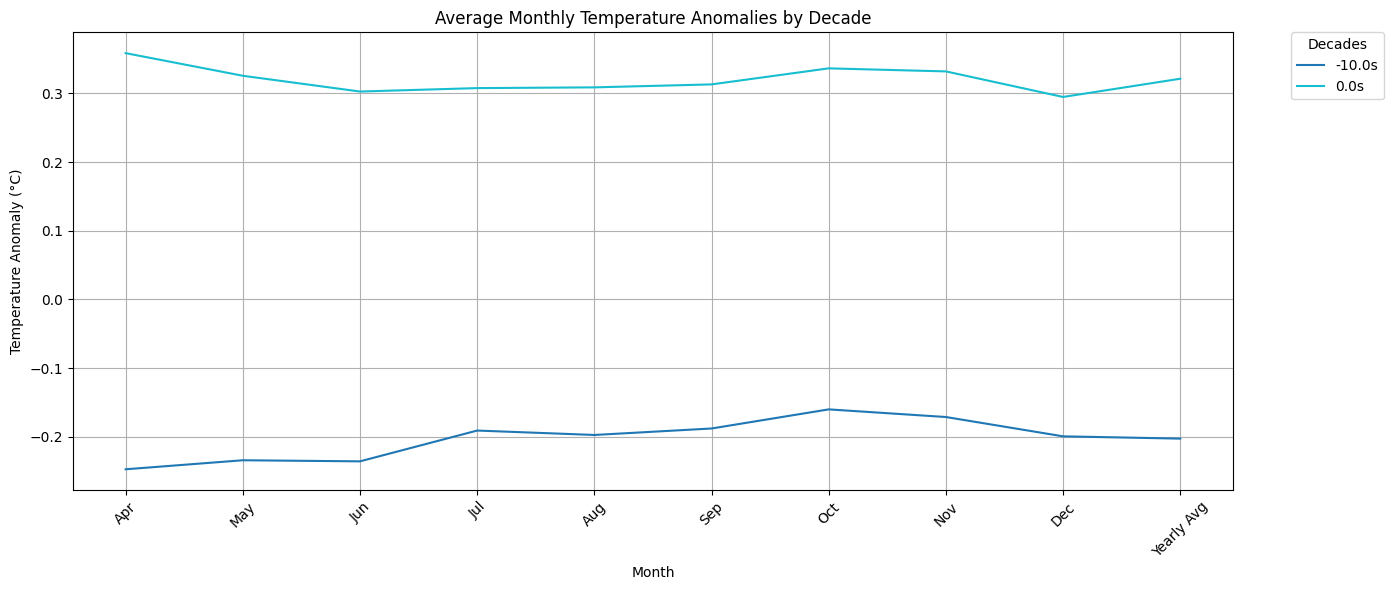

In [58]:
import matplotlib.pyplot as plt

monthly_data = df.iloc[:, :12].copy()

monthly_data['Decade'] = (monthly_data.index // 10) * 10

decade_monthly_avg = monthly_data.groupby('Decade').mean()

decade_monthly_avg = decade_monthly_avg.transpose()

plt.figure(figsize=(14, 6))

colormap = plt.get_cmap('tab10', len(decade_monthly_avg.columns))

for i, decade in enumerate(decade_monthly_avg.columns):
    plt.plot(decade_monthly_avg.index, decade_monthly_avg[decade],
             label=f'{decade}s', color=colormap(i))

plt.title('Average Monthly Temperature Anomalies by Decade')
plt.xlabel('Month')
plt.ylabel('Temperature Anomaly (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Decades", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., prop={'size': 10})

plt.tight_layout()
plt.show()


---------------

#### Bonus

Use seaborn to plot the `DataFrame` as a heatmap. The $y$-axis should be the month and the $x$-axis should be the year. The $z$-axis (the color of the heatmap) should represent the temperature anomaly. Choose a color palette that you think will be a good way of representating the data: https://matplotlib.org/examples/color/colormaps_reference.html.